In [1]:
import pandas as pd

df_control = pd.read_csv("df_control_updated.csv")
df_test = pd.read_csv("df_test_updated.csv")

## Hypothesis

Null Hypothesis ($H_0$)): For each step of the process, the mean completion time is the equal between the Test and Control groups.

Alternative Hypothesis ($H_a$)): For each step of the process, the mean completion time differs between the Test and Control groups.

In [2]:
df_test.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56
1,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03
2,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35
3,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14
4,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34


In [3]:
df_control.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,visitor_id,visit_id,process_step,date_time
0,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,start,2017-04-08 18:51:28
1,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:52:17
2,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:53:20
3,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 18:53:29
4,1028,12.0,145.0,36.0,M,3.0,103520.22,1.0,4.0,Control,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04


In [4]:
# converting the "date_time" into a datetime type
df_control["date_time"] = pd.to_datetime(df_control["date_time"])
df_test["date_time"] = pd.to_datetime(df_test["date_time"])

In [5]:
df_test['process_step'].unique()

<StringArray>
['start', 'step_1', 'step_2', 'step_3', 'confirm', nan]
Length: 6, dtype: str

In [6]:
# Droping missing values
df_test = df_test.dropna(subset=["process_step"])

In [7]:
df_test['process_step'].unique()

<StringArray>
['start', 'step_1', 'step_2', 'step_3', 'confirm']
Length: 5, dtype: str

## Analysis on process step for test group

In [8]:
df_test['visit_id'].unique()

<StringArray>
['637149525_38041617439_716659',  '40369564_40101682850_311847',
   '7076463_57954418406_971348', '583743392_96265099036_939815',
 '614001770_19101025926_112779',  '27144337_83739845380_214282',
 '255400977_38039535960_779641', '481123290_95510977345_707323',
  '379946188_1773022140_107963', '633860590_96880450633_976109',
 ...
 '448452610_76147168193_961371', '699981922_52880598802_858635',
 '149965839_24823291142_245569', '982803842_91891255980_123078',
 '288904166_90826265353_276104', '182723364_27031318473_880901',
  '493310979_9209676464_421146', '870243567_56915814033_814203',
  '99583652_41711450505_426179', '472154369_16714624241_585315']
Length: 37131, dtype: str

In [9]:
df_test[df_test['visit_id']=='100012776_37918976071_457913'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
52933,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09


In [10]:
df_test[df_test['visit_id']=='100019538_17884295066_43909'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
110695,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12
110696,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21
110697,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:35
110698,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:41
110699,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:21:59
110700,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:22:04
110701,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:22:08
110702,7338123,612065484_94198474375,100019538_17884295066_43909,step_3,2017-04-09 16:24:01
110703,7338123,612065484_94198474375,100019538_17884295066_43909,confirm,2017-04-09 16:24:58


In [11]:
df_test[df_test['visit_id']=='100022086_87870757897_149620'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
37141,2478628,754122351_18568832435,100022086_87870757897_149620,start,2017-05-23 20:44:01
37142,2478628,754122351_18568832435,100022086_87870757897_149620,step_1,2017-05-23 20:44:23
37143,2478628,754122351_18568832435,100022086_87870757897_149620,step_2,2017-05-23 20:45:08
37144,2478628,754122351_18568832435,100022086_87870757897_149620,step_3,2017-05-23 20:46:01
37145,2478628,754122351_18568832435,100022086_87870757897_149620,confirm,2017-05-23 20:47:01


In [12]:
df_test[df_test['visit_id']=='999988789_76411676596_272843'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
99510,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:49:22
99511,6627522,730634087_44272418812,999988789_76411676596_272843,step_2,2017-04-21 23:50:16
99512,6627522,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:51:00
99513,6627522,730634087_44272418812,999988789_76411676596_272843,start,2017-04-21 23:51:09


In [13]:
df_test[df_test['visit_id']=='999984454_18731538378_781808'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
12627,829911,648229874_89449279372,999984454_18731538378_781808,start,2017-03-29 11:18:33
12628,829911,648229874_89449279372,999984454_18731538378_781808,step_1,2017-03-29 11:18:51
12629,829911,648229874_89449279372,999984454_18731538378_781808,step_2,2017-03-29 11:19:32
12630,829911,648229874_89449279372,999984454_18731538378_781808,step_3,2017-03-29 11:20:23
12631,829911,648229874_89449279372,999984454_18731538378_781808,confirm,2017-03-29 11:21:07


In [14]:
df_test[df_test['visit_id']=='999976049_95772503197_182554'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
66226,4449968,842902495_57580498240,999976049_95772503197_182554,start,2017-04-04 12:50:10
66227,4449968,842902495_57580498240,999976049_95772503197_182554,step_1,2017-04-04 12:52:26
66228,4449968,842902495_57580498240,999976049_95772503197_182554,step_2,2017-04-04 12:53:01
66229,4449968,842902495_57580498240,999976049_95772503197_182554,step_3,2017-04-04 12:54:54
66230,4449968,842902495_57580498240,999976049_95772503197_182554,step_3,2017-04-04 12:59:35
66231,4449968,842902495_57580498240,999976049_95772503197_182554,confirm,2017-04-04 13:02:18


In [15]:
df_test[df_test['visit_id']=='999971096_28827267783_236076'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
44578,2979920,830229399_73416253406,999971096_28827267783_236076,start,2017-04-13 10:31:49
44579,2979920,830229399_73416253406,999971096_28827267783_236076,step_1,2017-04-13 10:32:07
44580,2979920,830229399_73416253406,999971096_28827267783_236076,step_1,2017-04-13 10:32:44
44581,2979920,830229399_73416253406,999971096_28827267783_236076,step_2,2017-04-13 10:32:53
44582,2979920,830229399_73416253406,999971096_28827267783_236076,step_3,2017-04-13 10:33:40
44583,2979920,830229399_73416253406,999971096_28827267783_236076,confirm,2017-04-13 10:34:08


In [16]:
df_test[df_test['visit_id']=='10029965_1592382589_593999'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
117042,7760839,111195013_39389847324,10029965_1592382589_593999,start,2017-04-20 12:28:02
117043,7760839,111195013_39389847324,10029965_1592382589_593999,step_1,2017-04-20 12:29:09


## Analysis on process step for control group

In [17]:
df_control['visit_id'].unique()

<StringArray>
['557292053_87239438319_391157', '543158812_46395476577_767725',
  '643221571_99977972121_69283', '507052512_11309370126_442139',
 '795373564_99931517312_810896', '393817425_39015278493_996341',
  '71862471_21202285428_848395', '784065271_45379483290_309335',
  '848231744_22569944243_37711',  '182925466_27021409208_83502',
 ...
 '200256953_19881035574_656660', '713500557_31297619237_860300',
    '19940015_3197786491_51650', '983995660_11938398128_321832',
  '84654768_90613632047_633963', '655572400_94971272893_411965',
  '761490147_96352537762_21814',  '904791598_9725982898_416914',
 '189177304_69869411700_783154',   '378424178_59565976155_8051']
Length: 32181, dtype: str

In [18]:
df_control[df_control['visit_id']=='557292053_87239438319_391157'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
0,1028,42237450_62128060588,557292053_87239438319_391157,start,2017-04-08 18:51:28
1,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:52:17
2,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:53:20
3,1028,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 18:53:29
4,1028,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04
5,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:59:55
6,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 19:00:15
7,1028,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 19:00:17
8,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 19:00:26


In [19]:
df_control[df_control['visit_id']=='507052512_11309370126_442139'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
11,1186,446844663_31615102958,507052512_11309370126_442139,start,2017-04-08 15:59:16


In [20]:
df_control[df_control['visit_id']=='643221571_99977972121_69283'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
10,1104,194240915_18158000533,643221571_99977972121_69283,start,2017-06-20 22:31:33


In [21]:
df_control[df_control['visit_id']=='507052512_11309370126_442139'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
11,1186,446844663_31615102958,507052512_11309370126_442139,start,2017-04-08 15:59:16


In [22]:
df_control[df_control['visit_id']=='795373564_99931517312_810896'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
12,1186,446844663_31615102958,795373564_99931517312_810896,start,2017-04-08 18:05:02
13,1186,446844663_31615102958,795373564_99931517312_810896,step_1,2017-04-08 18:05:13
14,1186,446844663_31615102958,795373564_99931517312_810896,step_2,2017-04-08 18:05:24


In [23]:
df_control[df_control['visit_id']=='393817425_39015278493_996341'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
15,1195,766842522_69992551638,393817425_39015278493_996341,start,2017-04-05 20:15:26
16,1195,766842522_69992551638,393817425_39015278493_996341,step_1,2017-04-05 20:15:59
17,1195,766842522_69992551638,393817425_39015278493_996341,step_2,2017-04-05 20:17:37
18,1195,766842522_69992551638,393817425_39015278493_996341,step_3,2017-04-05 20:18:08
19,1195,766842522_69992551638,393817425_39015278493_996341,confirm,2017-04-05 20:19:31


In [24]:
df_control[df_control['visit_id']=='71862471_21202285428_848395'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
20,1197,753759429_54481946928,71862471_21202285428_848395,start,2017-04-01 17:16:24
21,1197,753759429_54481946928,71862471_21202285428_848395,step_1,2017-04-01 17:16:28
22,1197,753759429_54481946928,71862471_21202285428_848395,step_2,2017-04-01 17:16:34
23,1197,753759429_54481946928,71862471_21202285428_848395,step_3,2017-04-01 17:17:25
24,1197,753759429_54481946928,71862471_21202285428_848395,step_2,2017-04-01 17:17:36
25,1197,753759429_54481946928,71862471_21202285428_848395,step_3,2017-04-01 17:17:42
26,1197,753759429_54481946928,71862471_21202285428_848395,confirm,2017-04-01 17:17:59


In [25]:
df_control[df_control['visit_id']=='784065271_45379483290_309335'][['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time']].sort_values(by='date_time', ascending=True)

,client_id,visitor_id,visit_id,process_step,date_time
27,1368,366307863_19014662045,784065271_45379483290_309335,start,2017-04-09 21:58:28


In [26]:
# Let's clean each group by creating a reusable function
def prepare_group(df):
    df = df.copy()
    
    # Sort by user and time
    df = df.sort_values(["visit_id", "date_time"])

    # Compute time between steps (consecutive)
    df["time_spent"] = df.groupby("visit_id")["date_time"].diff().dt.total_seconds()
    
    # Remove start (no time)
    df = df[df["process_step"] != "start"]
    
    return df

In [27]:
df_test_clean = prepare_group(df_test)
df_control_clean = prepare_group(df_control)

In [28]:
# Removing negative times
df_test_clean = df_test_clean[df_test_clean["time_spent"] >= 0]
df_control_clean = df_control_clean[df_control_clean["time_spent"] >= 0]

## Analysing outliers

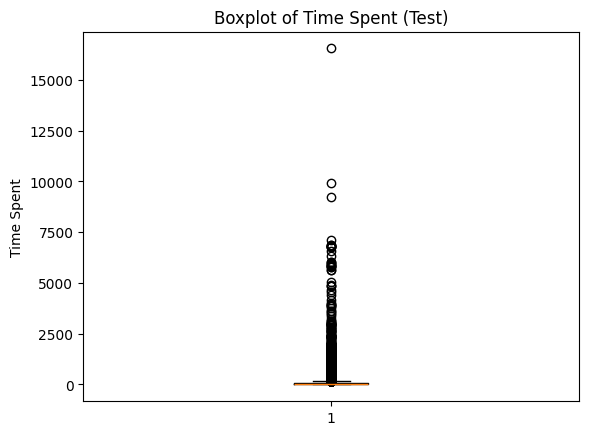

In [29]:
import matplotlib.pyplot as plt

plt.boxplot(df_test_clean["time_spent"].dropna())
plt.title("Boxplot of Time Spent (Test)")
plt.ylabel("Time Spent")
plt.show()

In [30]:
# Removing outliers for test group
upper = df_test_clean["time_spent"].quantile(0.99)
#df_test_clean["time_spent_capped"] = df_test_clean["time_spent"].clip(upper=upper)
df_test_clean["time_spent"] = df_test_clean["time_spent"].clip(upper=upper) #over-writing the same column so that we don't have to create a new column

In [31]:
#print(df_test_clean["time_spent"].max()) --> 14581
#print(df_test_clean["time_spent_capped"].max()) --> 873

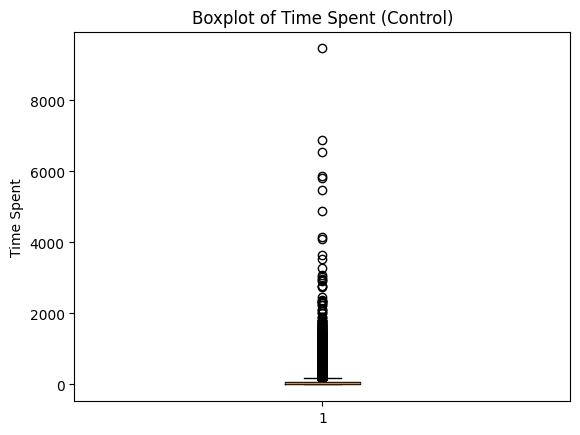

In [32]:
import matplotlib.pyplot as plt

plt.boxplot(df_control_clean["time_spent"].dropna())
plt.title("Boxplot of Time Spent (Control)")
plt.ylabel("Time Spent")
plt.show()

In [33]:
# Removing outliers for control group
upper = df_control_clean["time_spent"].quantile(0.99)
#df_control_clean["time_spent_capped"] = df_control_clean["time_spent"].clip(upper=upper)
df_control_clean["time_spent"] = df_control_clean["time_spent"].clip(upper=upper) #over-writing the same column so that we don't have to create a new column

In [34]:
#print(df_control_clean["time_spent"].max())  --> 9396
#print(df_control_clean["time_spent_capped"].max()) --> 587

## TEST GROUP

**Let's check if the completion times of all the steps of the process are the same for test group:**


In [35]:
# For test group
from scipy.stats import f_oneway

# Group and aggregate data
df_test_agg = df_test_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().unstack() # converts from long to wide format and averafe time spent when arriving at each step

step_order = ["step_1", "step_2", "step_3", "confirm"]
df_test_agg = df_test_agg[step_order]

# Drop missing - keep only complete funnels
df_test_agg = df_test_agg.dropna()

# Ensure numeric data
df_test_agg = df_test_agg.apply(pd.to_numeric, errors="coerce")

# ANOVA
f_stat, p_value = f_oneway(
    df_test_agg["step_1"],
    df_test_agg["step_2"],
    df_test_agg["step_3"],
    df_test_agg["confirm"]
)

print("Test group p-value:", p_value)

Test group p-value: 0.0


In [36]:
# Average time for users who completed the funnel process
print(df_test_agg.mean())

process_step
step_1      34.252163
step_2      38.080406
step_3      91.469669
confirm    124.110781
dtype: float64


<Axes: xlabel='process_step'>

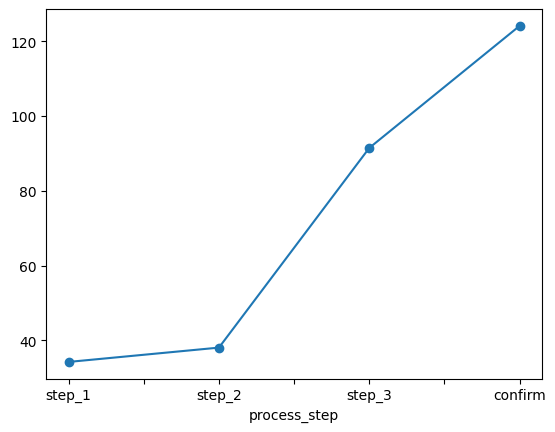

In [37]:
df_test_means = df_test_agg.mean()
df_test_means = df_test_means.reindex(step_order)
df_test_means.plot(kind="line", marker='o')

## CONTROL GROUP

**Let's check if the completion times of all the steps of the process are the same for control group:**

In [38]:
# For control group
from scipy.stats import f_oneway

df_control_agg = df_control_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().unstack()

df_control_agg = df_control_agg.apply(pd.to_numeric, errors="coerce")

step_order = ["step_1", "step_2", "step_3", "confirm"]
df_control_agg = df_control_agg[step_order]

df_control_agg = df_control_agg.dropna() 

f_stat, p_value = f_oneway(
    df_control_agg["step_1"],
    df_control_agg["step_2"],
    df_control_agg["step_3"],
    df_control_agg["confirm"]
)

print("Control group p-value:", p_value)

Control group p-value: 0.0


In [39]:
# Average time for users who completed the funnel process
print(df_control_agg.mean())

process_step
step_1      39.941273
step_2      35.213540
step_3      91.258470
confirm    126.970984
dtype: float64


<Axes: xlabel='process_step'>

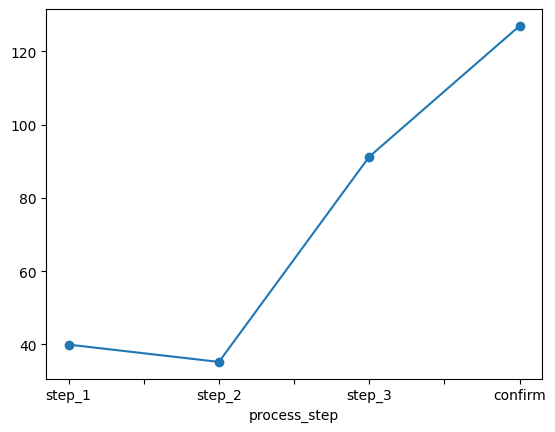

In [40]:
df_control_means = df_control_agg.mean()
df_control_means = df_control_means.reindex(step_order)
df_control_means.plot(kind="line", marker='o')

## TEST VS CONTROL

In [41]:
# Independent two-sample t-test
# Significance level = 5%
from scipy.stats import ttest_ind

# Test - Group by user and step, take the mean and keeps data in long format
df_test_agg = df_test_clean.groupby(
    ["visit_id", "process_step"]      
)["time_spent"].mean().reset_index()  

# Control - Group by user and step, take the mean and keeps data in long format
df_control_agg = df_control_clean.groupby(
    ["visit_id", "process_step"]
)["time_spent"].mean().reset_index()

# Loop through each step
steps = ["step_1", "step_2", "step_3", "confirm"]

# Extract values for each step
for step in steps:
    test_vals = df_test_agg[df_test_agg["process_step"] == step]["time_spent"].dropna()
    control_vals = df_control_agg[df_control_agg["process_step"] == step]["time_spent"].dropna()
    
    print(f"\nStep: {step}")
    print("Test size:", len(test_vals))
    print("Control size:", len(control_vals))
    print("Test std:", test_vals.std())
    print("Control std:", control_vals.std())
    
    if len(test_vals) > 1 and len(control_vals) > 1 and test_vals.std() > 0 and control_vals.std() > 0:
        t_stat, p_value = ttest_ind(test_vals, control_vals, equal_var=False)
        print("p-value:", p_value)
    else:
        print("Cannot compute t-test (data issue)")


Step: step_1
Test size: 25233
Control size: 21843
Test std: 89.18244982172344
Control std: 74.33491429708354
p-value: 0.7566071161259094

Step: step_2
Test size: 24371
Control size: 20050
Test std: 58.581002094004184
Control std: 48.462728612219216
p-value: 3.138294145852885e-22

Step: step_3
Test size: 21946
Control size: 18150
Test std: 89.30604673338725
Control std: 81.13295963175023
p-value: 0.9272496986050384

Step: confirm
Test size: 18246
Control size: 15191
Test std: 171.95165641559245
Control std: 132.13642714883431
p-value: 0.09999631417525949


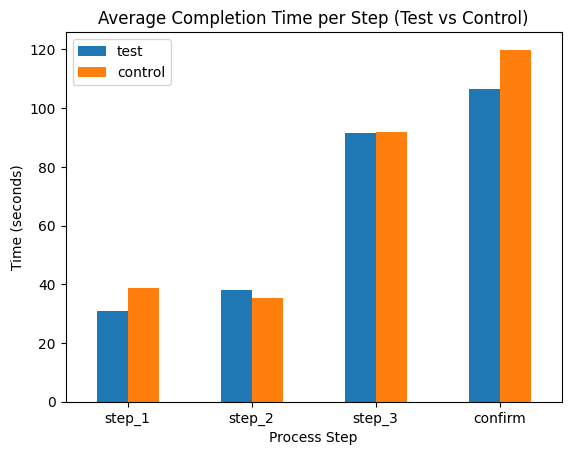

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    "step": ["step_1", "step_2", "step_3", "confirm"],
    "test": [30.91, 38.03, 91.46, 106.54],
    "control": [38.77, 35.19, 91.75, 119.87]
})

data = data.set_index("step")

data.plot(kind="bar")

plt.title("Average Completion Time per Step (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)

plt.show()

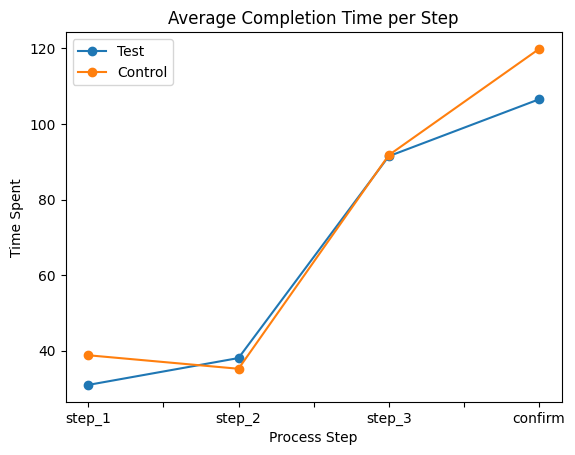

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
test = pd.Series({
    "step_1": 30.914139,
    "step_2": 38.028679,
    "step_3": 91.464122,
    "confirm":  106.536337
})

control = pd.Series({
    "step_1": 38.769089,
    "step_2": 35.192985,
    "step_3": 91.751055,
    "confirm": 119.866824
})

# Combine
df_plot = pd.DataFrame({
    "Test": test,
    "Control": control
})

# Plot
df_plot.plot(marker='o')
plt.title("Average Completion Time per Step")
plt.ylabel("Time Spent")
plt.xlabel("Process Step")
plt.xticks(rotation=0)
plt.show()

**Conclusions:**

After controlling for extreme outliers by capping values at the 99th percentile, the test variant shows a clear and statistically robust improvement in user efficiency across the funnel.

- In the first step, the average completion time decreased from 38.77 seconds (control) to 30.91 seconds (test), representing a reduction of approximately 7.86 seconds, which is highly statistically significant (p < 0.001).

- In the second step, the test group shows a small increase in completion time from 35.19 seconds to 38.03 seconds (difference of +2.84 seconds, p < 0.001). While statistically significant, the magnitude of this effect is relatively small and unlikely to have meaningful practical impact.

- For the third step, there is no meaningful difference between groups, with averages of 91.75 seconds (control) and 91.46 seconds (test), and the result is not statistically significant (p = 0.43), indicating that the experiment did not affect this stage.

- Most importantly, in the confirmation step — the critical conversion point — the test group shows a substantial reduction in completion time from 119.87 seconds (control) to 106.54 seconds (test), a decrease of approximately 13.33 seconds, which is highly statistically significant (p < 0.001).

Overall, the total completion time across all steps decreases from approximately 285.7 seconds (control) to 266.9 seconds (test), representing an improvement of about 19 seconds (~6–7%).

These results indicate that the test variant significantly improves the user experience, particularly by reducing friction at the beginning and at the most critical final step, while having no negative impact on the most complex stage of the process.

At a significance level of 5%, we reject the null hypothesis for steps 1, 2, and the confirmation step, as their p-values are all below 0.05. This indicates that the mean completion times differ significantly between the test and control groups for these steps.

For step 3, we fail to reject the null hypothesis (p = 0.43), indicating no statistically significant difference between the groups.

Therefore, the experiment has a statistically significant impact on most stages of the process, with the exception of step 3.

## Export to tableau

In [44]:
df_test_and_control = pd.concat([df_test_clean, df_control_clean])

In [45]:
df_tableau = (
    df_test_and_control
    .groupby(["variation", "visit_id", "process_step"])["time_spent"]
    .mean()
    .reset_index()
)

In [46]:
step_counts = df_tableau.groupby(["variation", "visit_id"])["process_step"].nunique()

complete_ids = step_counts[step_counts == 4].reset_index()[["variation", "visit_id"]]

df_tableau = df_tableau.merge(complete_ids, on=["variation", "visit_id"])

In [96]:
df_tableau.to_csv("completion_time_francisca.csv", index=False)